In [1]:
from lappy import *
from basis import BasisSpec, make_basis
import numpy as np
import matplotlib.pyplot as plt

In [9]:
def estimate_convergence_rate(n, err, plateau_factor=3.0, min_active_points=4):
    """
    Estimate whether `err` decays exponentially or algebraically in `n`,
    accounting for a possible noise/precision plateau at large n.

    Models compared (fit in log space via least squares):
        exponential: err(n) ~ C * exp(-alpha * n)   =>  log(err) = log(C) - alpha*n
        algebraic:   err(n) ~ C * n**(-p)            =>  log(err) = log(C) - p*log(n)

    Plateau handling
    -----------------
    Points whose error is within `plateau_factor` of the minimum observed
    error are assumed to be sitting on a noise/precision floor rather than
    still converging, and are excluded from the fit (but used to report
    the floor level).

    Parameters
    ----------
    n : array_like
        Independent variable (e.g. resolution, number of terms). Must be > 0.
    err : array_like
        Error values, assumed positive (absolute error / residual norm etc).
    plateau_factor : float
        A point is considered "plateaued" if err <= plateau_factor * min(err).
        Larger values are more aggressive about trimming the tail.
    min_active_points : int
        Minimum number of non-plateaued points required to trust the fit.
        If fewer are available, all points are used and `plateau_reliable`
        is set to False.

    Returns
    -------
    dict with keys:
        'type'        : 'exponential', 'algebraic', or 'inconclusive'
        'rate'        : alpha (if exponential) or p (if algebraic)
        'prefactor'   : C in the fitted model
        'r2_exp', 'r2_alg' : R^2 of each candidate fit (log space)
        'plateau_detected' : bool, whether any points were trimmed
        'plateau_reliable' : bool, whether enough active points remained
        'floor_estimate'   : estimated noise floor (mean of plateaued err), or None
        'n_active'    : the n-values actually used in the winning fit
        'active_mask' : boolean mask into the (sorted) input arrays
    """
    n = np.asarray(n, dtype=float)
    err = np.asarray(err, dtype=float)

    if n.shape != err.shape:
        raise ValueError("n and err must have the same shape")
    if np.any(n <= 0):
        raise ValueError("n must be strictly positive (needed for log(n))")
    if np.any(err <= 0):
        raise ValueError("err must be strictly positive")

    order = np.argsort(n)
    n = n[order]
    err = err[order]

    err_min = np.min(err)
    plateau_mask = err <= plateau_factor * err_min
    active_mask = ~plateau_mask

    plateau_detected = np.any(plateau_mask)
    floor_estimate = np.mean(err[plateau_mask]) if plateau_detected else None

    n_active_pts = np.sum(active_mask)
    plateau_reliable = True
    if n_active_pts < min_active_points:
        # not enough clean points to trust the trim -- fall back to all data
        active_mask = np.ones_like(err, dtype=bool)
        plateau_reliable = False

    n_fit = n[active_mask]
    err_fit = err[active_mask]
    log_err = np.log(err_fit)

    def _linfit_r2(x, y):
        # least squares line y = a*x + b, plus R^2
        A = np.vstack([x, np.ones_like(x)]).T
        (a, b), _, _, _ = np.linalg.lstsq(A, y, rcond=None)
        y_pred = a * x + b
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 1.0
        return a, b, r2

    # Exponential model: log(err) vs n
    alpha_slope, log_C_exp, r2_exp = _linfit_r2(n_fit, log_err)
    alpha = -alpha_slope
    C_exp = np.exp(log_C_exp)

    # Algebraic model: log(err) vs log(n)
    p_slope, log_C_alg, r2_alg = _linfit_r2(np.log(n_fit), log_err)
    p = -p_slope
    C_alg = np.exp(log_C_alg)

    # Decide winner
    r2_tol = 0.02  # require a meaningfully better fit, not just noise
    if max(r2_exp, r2_alg) < 0.5:
        kind = "inconclusive"
        rate, prefactor = np.nan, np.nan
    elif r2_exp > r2_alg + r2_tol:
        kind = "exponential"
        rate, prefactor = alpha, C_exp
    elif r2_alg > r2_exp + r2_tol:
        kind = "algebraic"
        rate, prefactor = p, C_alg
    else:
        # too close to call cleanly; report the nominally better one but flag it
        if r2_exp >= r2_alg:
            kind = "exponential"
            rate, prefactor = alpha, C_exp
        else:
            kind = "algebraic"
            rate, prefactor = p, C_alg

    return {
        "type": kind,
        "rate": rate,
        "prefactor": prefactor,
        "r2_exp": r2_exp,
        "r2_alg": r2_alg,
        "plateau_detected": bool(plateau_detected),
        "plateau_reliable": bool(plateau_reliable),
        "floor_estimate": floor_estimate,
        "n_active": n_fit,
        "active_mask": active_mask,
    }

# L-shape

In [37]:
dom = geometry.L_shape()
eig = reference.L_shape_eigs(1)[0]
bs = BasisSpec()

N_target = np.arange(10,121,1)
max_basis = make_basis(dom, N_target.max(), bs)
bdry_pts = mps.make_default_bdry_data(dom, max_basis)[0]
int_pts = dom.int_pts(npts_rand=len(max_basis))

tension = np.empty(len(N_target))
N_basis = np.empty_like(N_target)
for i,n in enumerate(N_target):
    basis = make_basis(dom, n, bs)
    N_basis[i] = len(basis)
    normed_basis = NormalizedBasis(basis, (bdry_pts, int_pts))
    solver = MPSEigensolver(normed_basis, bdry_pts, int_pts)
    tension[i] = solver.sigma(eig)
convergence_dict = estimate_convergence_rate(N_basis, tension)

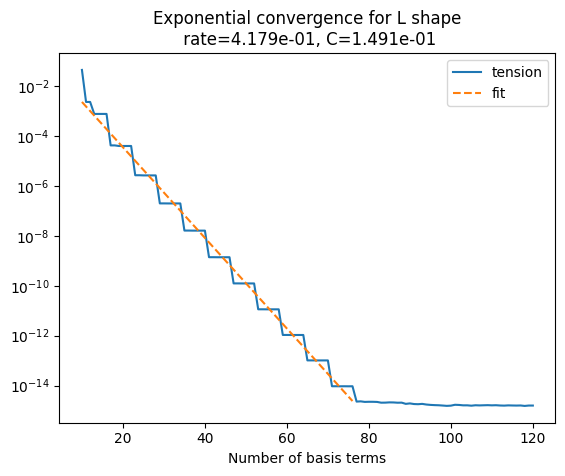

In [39]:
cd = convergence_dict
dom_name = "L shape"
if cd['type'] == 'exponential':
    plt.semilogy(N_basis, tension, label='tension')
    plt.semilogy(cd['n_active'], cd['prefactor']*np.exp(-cd['rate']*cd['n_active']), ls='dashed', label='fit')
    plt.title(f"Exponential convergence for {dom_name}\n rate={cd['rate']:.3e}, C={cd['prefactor']:.3e}")
elif cd['type'] == 'algebraic':
    plt.loglog(N_basis, tension, label='tension')
    plt.loglog(cd['n_active'], cd['prefactor']*(cd['n_active']**(-cd['rate'])), ls='dashed', label='fit')
    plt.title(f"Exponential convergence for {dom_name}\n rate={cd['rate']:.3e}, C={cd['prefactor']:.3e}")
plt.xlabel("Number of basis terms")
plt.legend()
plt.show()

In [59]:
dom = geometry.iso_tri(h=8.0)
eig = reference.iso_tri_eigs(1, h=8.0)[0]
bs = BasisSpec()

N_target = np.arange(10,301,10)
max_basis = make_basis(dom, N_target.max(), bs)
bdry_pts = mps.make_default_bdry_data(dom, max_basis)[0]
int_pts = dom.int_pts(npts_rand=len(max_basis))

tension = np.empty(len(N_target))
N_basis = np.empty_like(N_target)
for i,n in enumerate(N_target):
    basis = make_basis(dom, n, bs)
    N_basis[i] = len(basis)
    normed_basis = NormalizedBasis(basis, (bdry_pts, int_pts))
    solver = MPSEigensolver(normed_basis, bdry_pts, int_pts)
    tension[i] = solver.sigma(eig)
convergence_dict = estimate_convergence_rate(N_basis, tension)

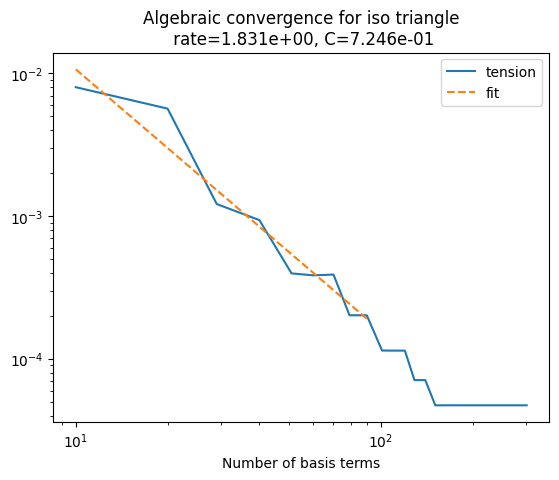

In [60]:
cd = convergence_dict
dom_name = "iso triangle"
if cd['type'] == 'exponential':
    plt.semilogy(N_basis, tension, label='tension')
    plt.semilogy(cd['n_active'], cd['prefactor']*np.exp(-cd['rate']*cd['n_active']), ls='dashed', label='fit')
    plt.title(f"Exponential convergence for {dom_name}\n rate={cd['rate']:.3e}, C={cd['prefactor']:.3e}")
elif cd['type'] == 'algebraic':
    plt.loglog(N_basis, tension, label='tension')
    plt.loglog(cd['n_active'], cd['prefactor']*(cd['n_active']**(-cd['rate'])), ls='dashed', label='fit')
    plt.title(f"Algebraic convergence for {dom_name}\n rate={cd['rate']:.3e}, C={cd['prefactor']:.3e}")
plt.xlabel("Number of basis terms")
plt.legend()
plt.show()

In [86]:
dom = geometry.iso_tri(h=8.0)
bs = BasisSpec(fs_bdry_frac=0.9)

N_target = np.arange(10,501,20)
max_basis = make_basis(dom, N_target.max(), bs)
bdry_pts = mps.make_default_bdry_data(dom, max_basis)[0]
int_pts = dom.int_pts(npts_rand=len(max_basis))
normed_max_basis = NormalizedBasis(max_basis, (bdry_pts, int_pts))
solver_max = MPSEigensolver(normed_max_basis, bdry_pts, int_pts, ltol=1e-15)
eigs, mults, fevals = solver.solve_interval(4.7, 4.8, 10, verbose=True)
eig = eigs[0]
print(eig, solver_max.sigma(eig))

tension = np.empty(len(N_target))
N_basis = np.empty_like(N_target)
for i,n in enumerate(N_target):
    basis = make_basis(dom, n, bs)
    N_basis[i] = len(basis)
    normed_basis = NormalizedBasis(basis, (bdry_pts, int_pts))
    solver = MPSEigensolver(normed_basis, bdry_pts, int_pts, ltol=1e-15)
    tension[i] = solver.sigma(eig)/solver.sigma(1)
convergence_dict = estimate_convergence_rate(N_basis, tension)

solve_interval on [4.70000e+00,4.80000e+00], n_pts=10
1. evaluating tensions on lamgrid...


100%|███████████████████████████████████████████| 12/12 [00:05<00:00,  2.14it/s]


2. finding eigenvalue brackets...
3. minimizing tension on brackets...
4. sorting & merging eigenvalues...
5. filtering eigenvalues...
6. estimating multiplicities...
***found 1 eigenvalues, total_mult=1, fevals=22***
4.719098710033822 2.368145892155129e-13


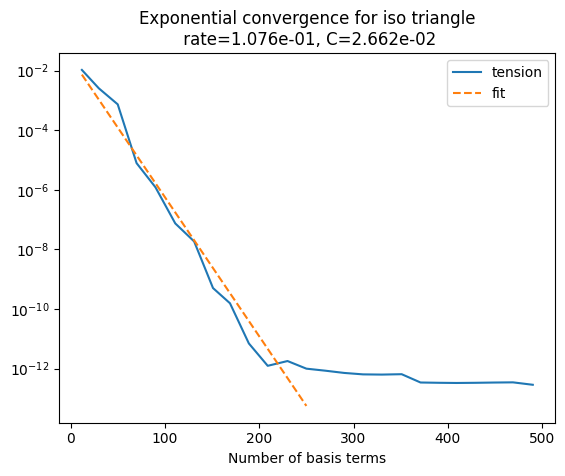

In [87]:
cd = convergence_dict
dom_name = "iso triangle"
if cd['type'] == 'exponential':
    plt.semilogy(N_basis, tension, label='tension')
    plt.semilogy(cd['n_active'], cd['prefactor']*np.exp(-cd['rate']*cd['n_active']), ls='dashed', label='fit')
    plt.title(f"Exponential convergence for {dom_name}\n rate={cd['rate']:.3e}, C={cd['prefactor']:.3e}")
elif cd['type'] == 'algebraic':
    plt.loglog(N_basis, tension, label='tension')
    plt.loglog(cd['n_active'], cd['prefactor']*(cd['n_active']**(-cd['rate'])), ls='dashed', label='fit')
    plt.title(f"Algebraic convergence for {dom_name}\n rate={cd['rate']:.3e}, C={cd['prefactor']:.3e}")
plt.xlabel("Number of basis terms")
plt.legend()
plt.show()

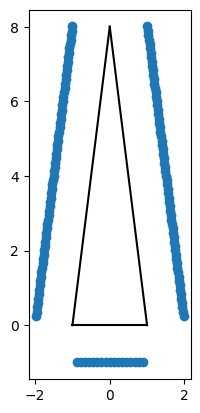

In [74]:
fix, ax = plt.subplots()
dom.plot(ax=ax)
ax.set_aspect('equal')
ax.plot(max_basis.bases[1].sources.real, max_basis.bases[1].sources.imag, 'o')
plt.show()

In [89]:
solver_max.sigma(4.719098710033822), solver_max.sigma(reference.iso_tri_eigs(1, h=8.0)[0])

(np.float64(2.368145892155129e-13), np.float64(2.3663165173784236e-13))